To start off, we look at the data: 
- We see the files it has 
- The shapes of the each image and label
- Plot the first 5 training images

In [13]:
import numpy as np
from sklearn.svm import LinearSVC
data = np.load('octmnist.npz')
print("Keys in octmnist.npz: ", data.files)

for k in data.files:
    arr = data[k]
    print(f"{k:>12}: shape = {arr.shape}")

Keys in octmnist.npz:  ['train_images', 'val_images', 'test_images', 'train_labels', 'val_labels', 'test_labels']
train_images: shape = (97477, 28, 28)
  val_images: shape = (10832, 28, 28)
 test_images: shape = (1000, 28, 28)
train_labels: shape = (97477, 1)
  val_labels: shape = (10832, 1)
 test_labels: shape = (1000, 1)


In [14]:
train_images = data["train_images"]
train_labels = data["train_labels"].ravel()

val_images = data["val_images"]
val_labels = data["val_labels"].ravel()

test_images = data["test_images"]
test_labels = data["test_labels"].ravel()

print("Train:", train_images.shape, train_labels.shape)
print("Val:  ", val_images.shape, val_labels.shape)
print("Test: ", test_images.shape, test_labels.shape)

print("train_images pixel min/max", train_images.min(), train_images.max())

Train: (97477, 28, 28) (97477,)
Val:   (10832, 28, 28) (10832,)
Test:  (1000, 28, 28) (1000,)
train_images pixel min/max 0 255


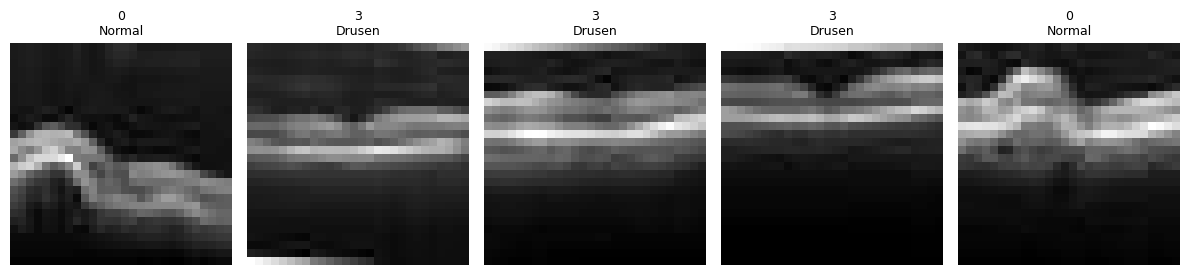

In [15]:
import matplotlib.pyplot as plt
label_names = {
    0: "Normal",
    1: "Choroidal neovascularization",
    2: "Diabetic macular edema",
    3: "Drusen"
}

plt.figure(figsize=(12,3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(train_images[i], cmap="gray")
    label = int(train_labels[i])
    plt.title(f"{label}\n{label_names.get(label, '')}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

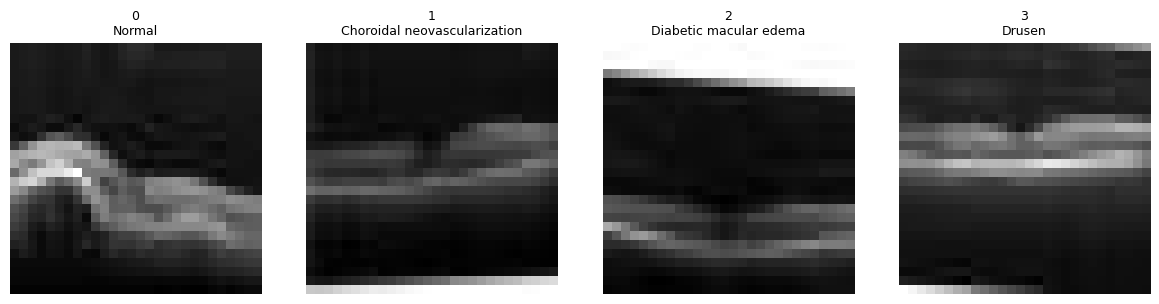

In [16]:
plt.figure(figsize=(12, 3))
for i in range(4):
    plt.subplot(1, 4, i+1)
    idx = np.flatnonzero(train_labels == i)[0]
    plt.imshow(train_images[idx], cmap="gray")
    plt.title(f"{i}\n{label_names[i]}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [17]:
val_images.shape
#10k instances
#28 features by 28 features grid

def avg_2x2_pool(array):
    '''Reduced dimensionality of a 3d square array by half
    Takes the average of neighboring squares to find value'''

    x, y, z = array.shape

    reduced_array = np.zeros((x, int(y/2), int(z/2)))
    for i in range(x):
        for j in range(0, y, 2):
            for k in range(0, z, 2):
                p0 = float(array[i][j][k])
                p1 = float(array[i][j][k+1])
                p2 = float(array[i][j+1][k])
                p3 = float(array[i][j+1][k+1])

                new_point = (p0 + p1 + p2 + p3)/4.0

                reduced_array[i][int(j/2)][int(k/2)] = new_point

    return reduced_array


In [18]:
def flatten_data(X):
    '''Flattens a 3D array into a 2D one'''
    new_arr = X.reshape(X.shape[0], -1)
    return new_arr

In [19]:
def max_2x2_pool(array):
    '''Reduces the dimensions of a 3D square array by half
     takes the max of neighboring squares to determine the value '''
    x, y, z = array.shape

    reduced_array = np.zeros((x, y//2, z//2), dtype=np.float32)

    for i in range(x):
        for j in range(0, y, 2):
            for k in range(0, z, 2):
                p0 = float(array[i][j][k])
                p1 = float(array[i][j][k+1])
                p2 = float(array[i][j+1][k])
                p3 = float(array[i][j+1][k+1])

                reduced_array[i][j//2][k//2] = max(p0, p1, p2, p3)

    return reduced_array

In [20]:
def median_filter_2d(img2d, size=3):
    '''Takes in a 2d array and looks at nearby pixels in radius of size
    it will then sort those pixels and replace pixel at that position of arr
    with the median value'''

    x, y = img2d.shape
    r = size//2

    arr = np.zeros((x, y), dtype=float)

    for i in range(x):
        for j in range(y):
            window = []
            for ri in range(-r, r + 1):
                for rj in range(-r, r + 1):
                    ii = i + ri
                    jj = j + rj

                    #out of bounds
                    if ii < 0:
                        ii = 0
                    if ii >= x:
                        ii = x - 1
                    if jj < 0:
                        jj = 0
                    if jj >= y:
                        jj = y - 1

                    window.append(float(img2d[ii][jj]))
            window.sort()
            arr[i][j] = window[len(window)//2]
    return arr

In [10]:
def median_then_avg_pool(array, size=3):
    x, y, z = array.shape
    filtered = np.zeros((x, y, z), dtype=float)

    for i in range(x):
        filtered[i] = median_filter_2d(array[i].astype(np.float32), size=size)

    return avg_2x2_pool(filtered)

In [21]:
def basic_new_features(images):
    x, y, z = images.shape
    features = np.zeros((x, 7), dtype=float)

    for i in range(x):
        flat = images[i].reshape(-1).astype(np.float32)

        mean = float(flat.mean())
        std  = float(flat.std())
        mn   = float(flat.min())
        mx   = float(flat.max())
        med  = float(np.median(flat))
        q1   = float(np.percentile(flat, 25))
        q3   = float(np.percentile(flat, 75))

        features[i, 0] = mean
        features[i, 1] = std
        features[i, 2] = mn
        features[i, 3] = mx
        features[i, 4] = med
        features[i, 5] = q1
        features[i, 6] = q3

    return features

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import SVC

flattener = FunctionTransformer(flatten_data, validate=False)
reducer = FunctionTransformer(avg_2x2_pool, validate=False)
scalar = StandardScaler()
svc = LinearSVC() #since linear is a lot faster than normal SVC which is what we originally were using

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

#base pipeline (28x28 px)
pipe_baseline = Pipeline([
    ("flat", flattener),
    ("scale", scalar),
    ("model", svc)
])

#avg pool once (14x14 px)
pipe_avg14 = Pipeline([
    ("avg14", FunctionTransformer(avg_2x2_pool, validate=False)),
    ("flat", flattener),
    ("scale", scalar),
    ("model", svc)
])

#avg pool twice (7x7 px)
pipe_avg7 = Pipeline([
    ("avg14", FunctionTransformer(avg_2x2_pool, validate=False)),
    ("avg7", FunctionTransformer(avg_2x2_pool, validate=False)),
    ("flat", flattener),
    ("scale", scalar),
    ("model", svc)
])

#median filter + avg pool (median then 14x14 px)
pipe_median_avg14 = Pipeline([
    ("med_avg14", FunctionTransformer(lambda x: median_then_avg_pool(x, size=3), validate=False)),
    ("flat", flattener),
    ("scale", scalar),
    ("model", svc)
])

#max pool once (14x14 px)
pipe_max14 = Pipeline([
    ("max14", FunctionTransformer(max_2x2_pool, validate=False)),
    ("flat", flattener),
    ("scale", scalar),
    ("model", svc)
])


pipe_pca = Pipeline([
    ("flat", flattener),
    ("scale", scalar),
    ("pca", PCA(n_components=50)),
    ("model", svc)
])

#feature generation pipeline (7)
pipe_feature = Pipeline([
    ("features", FunctionTransformer(basic_new_features, validate=False)),
    ("scale", scalar),
    ("model", svc)
])

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
import time

def train_eval_model(name, model, x_tr, y_tr, x_va, y_va):
    '''trains and evaluates the model'''
    t1 = time.time()
    model.fit(x_tr, y_tr)
    t2 = time.time()

    #get predictions
    pred = model.predict(x_va)

    acc = accuracy_score(y_va, pred)
    prec = precision_score(y_va, pred, average="weighted", zero_division=1)
    recall = recall_score(y_va, pred, average="weighted", zero_division=1)

    print(f"Model: {name}")
    print(f"Training Time: {t2-t1:.3f}")
    print(f'acc: {acc:.4f}')
    print(f'prec:{prec:.4f}')
    print(f'recall:{recall:.4f}\n')

In [25]:
from sklearn.model_selection import StratifiedShuffleSplit

def stratified_subset(X, y, n_samples):
    n_samples = min(n_samples, X.shape[0])
    split = StratifiedShuffleSplit(n_splits=1, train_size=n_samples, random_state=42)
    idx, _ = next(split.split(X, y))
    return X[idx], y[idx]

#running on 22,000 and 2,000 for time purposes
x_tr, y_tr = stratified_subset(train_images, train_labels, 22000)
x_va, y_va = stratified_subset(val_images, val_labels, 2000)

In [ ]:
#train
train_eval_model("Baseline (784px)", pipe_baseline, x_tr, y_tr, x_va, y_va)
train_eval_model("Avg pool (196px)", pipe_avg14, x_tr, y_tr, x_va, y_va)
train_eval_model("Avg pool (49px)", pipe_avg7, x_tr, y_tr, x_va, y_va)
train_eval_model("Median filter then avg pool (196px)", pipe_median_avg14, x_tr, y_tr, x_va, y_va)
train_eval_model("Max pool (196px)", pipe_max14, x_tr, y_tr, x_va, y_va)
train_eval_model("PCA 50", pipe_pca, x_tr, y_tr, x_va, y_va)
train_eval_model("Generated features", pipe_feature, x_tr, y_tr, x_va, y_va)

c:\Users\samue\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
